# Estimating Swing Probability for Zac Gallen Pitches Using a Calibrated Random Forest Model

---
embed-resources: true
echo: false
---

---
format:
  html:
    toc: true
    toc-location: left
    toc-depth: 3
    number-sections: true
embed-resources: true
echo: false
---

## Introduction

This report develops a probability model to estimate whether a batter will swing at a pitch thrown by Zac Gallen. The purpose of the report is to help evaluate how pitch characteristics, pitch type, batter information, and game situation relate to swing behavior, and to build a model that can produce useful swing probabilities for future pitches. Because the goal is to predict probability rather than only classify swing or take, the report focuses on creating a well-calibrated model that gives reliable probability estimates.

The analysis uses Statcast pitch-level data from Zac Gallen’s 2023 regular season, split into training and test sets. The predictors include numeric variables such as release characteristics, pitch location, movement, count, baserunner situation, and strike zone measurements, along with categorical variables for pitch type and batter stance. To model swing probability, the report uses a preprocessing pipeline with missing value imputation and one-hot encoding, followed by a random forest classifier. The probability estimates are then further calibrated with CalibratedClassifierCV using sigmoid calibration to improve the quality of the predicted swing probabilities.

## Methods

### Imports

In [ ]:
# imports
import os
from joblib import dump
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import brier_score_loss

### Data

The original source of the data is [Statcast](https://en.wikipedia.org/wiki/Statcast). Specifically, the [pybaseball](https://pypi.org/project/pybaseball/) package was used to interface with [Statcast Search](https://baseballsavant.mlb.com/statcast_search), which is part of [Baseball Savant](https://baseballsavant.mlb.com/).

In [2]:
# Load data
swing_train = pd.read_parquet(
    "https://lab.cs307.org/swing/data/swing-train.parquet",
)
swing_test = pd.read_parquet(
    "https://lab.cs307.org/swing/data/swing-test.parquet",
)

### Data Dictionary
Each sample contains Statcast data for a single pitch thrown by Zac Gallen in the 2023 MLB regular season.

Baseball Savant: [Zac Gallen](https://baseballsavant.mlb.com/savant-player/zac-gallen-668678?stats=statcast-r-pitching-mlb)
Here, the train-test split is based on time.

Train: March 30 through August 31, 2023
Test: September 1 through October 2, 2023
Original and (mostly) complete documentation for Statcast data can be found in the [Statcast Search CSV Documentation](https://baseballsavant.mlb.com/csv-docs). A more detailed reference can be found in [Appendix C of Analyzing Baseball Data with R](https://beanumber.github.io/abdwr3e/C_statcast.html)

### Variable descriptions


**`swing`**

- `[int64]` Whether or not the batter swung (`1`) or took (`0`).

**`pitch_name`**

- `[object]` The name of the pitch type to be thrown.

**`release_extension`**

- `[float64]` Release extension of pitch in feet as tracked by Statcast.

**`release_pos_x`**

- `[float64]` Horizontal release position of the ball measured in feet from the catcher's perspective.

**`release_pos_y`**

- `[float64]` Release position of pitch measured in feet from the catcher's perspective.

**`release_pos_z`**

- `[float64]` Vertical release position of the ball measured in feet from the catcher's perspective.

**`release_speed`**

- `[float64]` Velocity of the pitch thrown (miles per hour).

**`release_spin_rate`**

- `[float64]` Spin rate of pitch tracked by Statcast (revolutions per minute).

**`spin_axis`**

- `[float64]` The spin axis in the 2D X-Z plane in degrees from 0 to 360, such that 180 represents a pure backspin fastball and 0 degrees represents a pure topspin (12-6) curveball.

**`plate_x`**

- `[float64]` Horizontal position of the ball when it crosses home plate from the catcher's perspective (feet).

**`plate_z`**

- `[float64]` Vertical position of the ball when it crosses home plate from the catcher's perspective (feet).

**`pfx_x`**

- `[float64]` Horizontal movement in feet from the catcher's perspective.

**`pfx_z`**

- `[float64]` Vertical movement in feet from the catcher's perspective.

**`balls`**

- `[int64]` Pre-pitch number of balls in count.

**`strikes`**

- `[int64]` Pre-pitch number of strikes in count.

**`on_3b`**

- `[int64]` Indicator (`0` or `1`) for runner on 3rd base.

**`on_2b`**

- `[int64]` Indicator (`0` or `1`) for runner on 2nd base.

**`on_1b`**

- `[int64]` Indicator (`0` or `1`) for runner on 1st base.

**`outs_when_up`**

- `[int64]` Pre-pitch number of outs.

**`stand`**

- `[object]` Side of the plate batter is standing, either `L` (left) or `R` (right).

**`sz_top`**

- `[float64]` Top of the batter's strike zone set by the operator when the ball is halfway to the plate (feet).

**`sz_bot`**

- `[float64]` Bottom of the batter's strike zone set by the operator when the ball is halfway to the plate (feet).

### Summary Statistics

#### 1. Number of samples/feature



In [3]:
# samples and features
n_samples = swing_train.shape[0]
n_features = swing_train.drop("swing", axis=1).shape[1]

print("Number of samples:", n_samples)
print("Number of features:", n_features)

Number of samples: 2663
Number of features: 21


#### 2. Swing Probability

In [4]:
# overall swing probability
overall_swing_rate = swing_train["swing"].mean()
print("\nAll:", round(overall_swing_rate, 6))


All: 0.477281


#### 3. swing probability by pitch type

In [5]:
# swing probability by pitch type
swing_by_pitch = swing_train.groupby("pitch_name")["swing"].mean().round(6)
print("\nSwing probability by pitch type:")
print(swing_by_pitch)


Swing probability by pitch type:
pitch_name
4-Seam Fastball    0.470904
Changeup           0.536313
Cutter             0.451477
Knuckle Curve      0.462875
Slider             0.496124
Name: swing, dtype: float64


### Exploratory Visualization

#### Pitch location by swing decision in the training data

@fig-swing-location shows that swung-at pitches are more concentrated near the center of the plate area, while taken pitches are more dispersed toward the edges. This suggests pitch location is related to swing behavior, although the overlap indicates that location alone does not fully determine whether a batter swings.

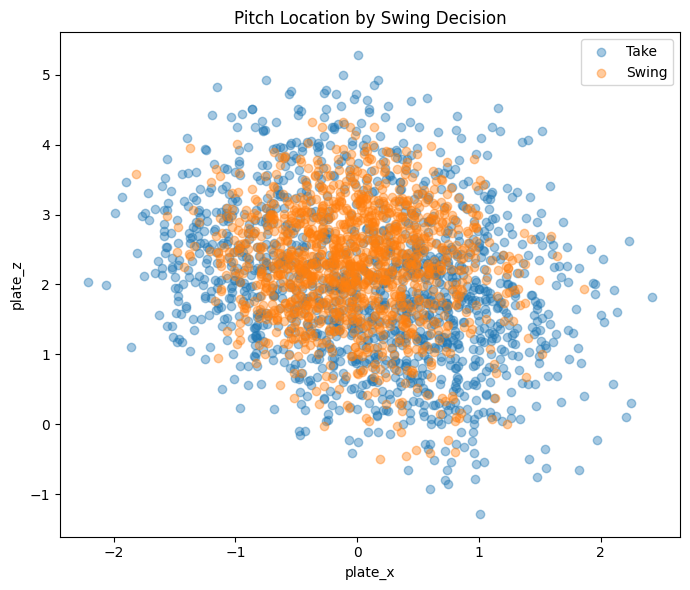

In [6]:
#| label: fig-swing-location
#| fig-cap: "Pitch location by swing decision in the training data."

swing_yes = swing_train[swing_train["swing"] == 1]
swing_no = swing_train[swing_train["swing"] == 0]

plt.figure(figsize=(7, 6))
plt.scatter(swing_no["plate_x"], swing_no["plate_z"], alpha=0.4, label="Take")
plt.scatter(swing_yes["plate_x"], swing_yes["plate_z"], alpha=0.4, label="Swing")
plt.title("Pitch Location by Swing Decision")
plt.xlabel("plate_x")
plt.ylabel("plate_z")
plt.legend()
plt.tight_layout()
plt.show()

#### Average swing probability by pitch type in the training data

@fig-swing-by-pitch shows that average swing rates differ across pitch types in the training data. Changeups have the highest swing rate and cutters the lowest, suggesting that pitch type may provide useful information for predicting swing probability.

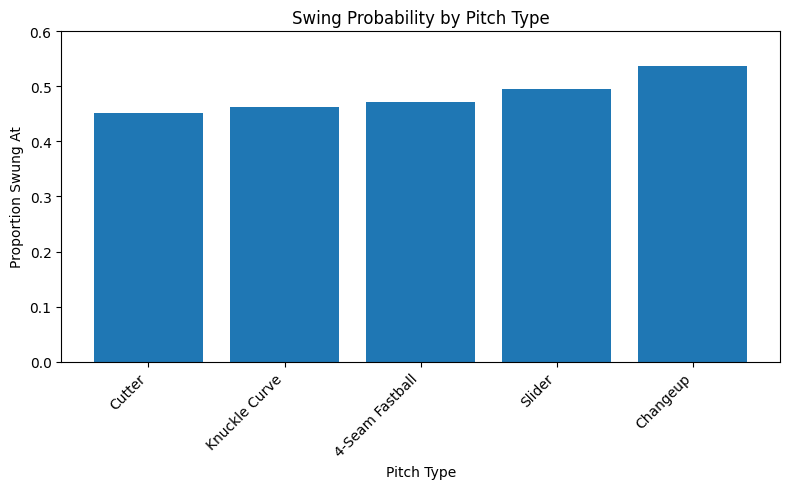

In [7]:
#| label: fig-swing-by-pitch
#| fig-cap: "Average swing probability by pitch type in the training data."

swing_by_pitch = (
    swing_train.groupby("pitch_name")["swing"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plt.bar(swing_by_pitch.index, swing_by_pitch.values)
plt.title("Swing Probability by Pitch Type")
plt.xlabel("Pitch Type")
plt.ylabel("Proportion Swung At")
plt.ylim(0, 0.6)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Models

#### Prepare Data for Machine Learning

To model swing probability, the response variable was defined as whether the batter swung at the pitch, and all remaining variables were used as predictors. 

In [8]:
# create X and y for train
X_train = swing_train.drop("swing", axis=1)
y_train = swing_train["swing"]

# create X and y for test
X_test = swing_test.drop("swing", axis=1)
y_test = swing_test["swing"]

Organizes the predictors into numeric and categorical feature groups.

In [9]:
numeric_features = [
    "release_extension",
    "release_pos_x",
    "release_pos_y",
    "release_pos_z",
    "release_speed",
    "release_spin_rate",
    "spin_axis",
    "plate_x",
    "plate_z",
    "pfx_x",
    "pfx_z",
    "balls",
    "strikes",
    "on_3b",
    "on_2b",
    "on_1b",
    "outs_when_up",
    "sz_top",
    "sz_bot",
]

categorical_features = [
    "pitch_name",
    "stand",
]

Defines the preprocessing steps for the model. Numeric variables are imputed with their median values, while categorical variables are imputed with their most frequent values and then converted into dummy variables using one-hot encoding.

In [10]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


A **Random Forest Classifier** was used because it can flexibly capture nonlinear patterns in the data. ince the main goal was to generate well-calibrated probabilities, the random forest predictions were further calibrated using sigmoid calibration with **5-fold** stratified cross-validation. 

In [11]:
base_model = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=90,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

final_model = CalibratedClassifierCV(
    estimator=base_model,
    method="sigmoid",
    cv=cv,
    ensemble=True
)

final_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to

## Results

The calibrated random forest model performed reasonably well on the test data. The model achieved an Expected Calibration Error (ECE) of 0.0522, a Maximum Calibration Error (MCE) of 0.1010, and a Brier Score of 0.1860. These results suggest that the predicted swing probabilities were fairly well calibrated and that the model was able to produce probability estimates that were close to the observed outcomes.

In [ ]:
# report model metrics
from calibration import calibration_error, plot_calibration_plot

ece = calibration_error(y_test, y_prob, type="expected", n_bins=10)
mce = calibration_error(y_test, y_prob, type="max", n_bins=10)

print("ECE:", ece)
print("MCE:", mce)

ECE: 0.052220428300291576
MCE: 0.10095544239895501
Brier Score: 0.18595673959410927


In [ ]:
y_prob = final_model.predict_proba(X_test)[:, 1]
y_pred = final_model.predict(X_test)

brier = brier_score_loss(y_test, y_prob)
print("Brier Score:", brier)

Brier Score: 0.18595673959410927


### Summary figure

The calibration plot in @fig-calibration-plot provides a visual summary of this performance. Most points lie close to the 45-degree reference line, suggesting that the predicted swing probabilities generally align well with the observed swing frequencies. The model shows some deviation from perfect calibration in the lower and middle probability ranges, but calibration appears stronger at higher predicted probabilities. Overall, the model provides usable probability estimates on the test data.

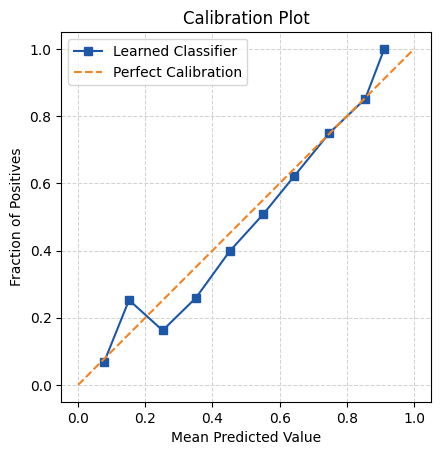

In [ ]:
#| label: fig-calibration-plot
#| fig-cap: "Calibration plot for the final calibrated random forest model on the test data."

plot_calibration_plot(y_test, y_prob)

In [15]:
# serialize model
dump(final_model, "swing.joblib", compress=9)

size_mb = os.path.getsize("swing.joblib") / (1024 * 1024)
print(f"File size: {size_mb:.2f} MB")

File size: 1.42 MB


## Discussion

Overall, the final calibrated random forest model produced useful probability estimates for whether a batter will swing at a pitch. The test metrics and calibration plot suggest that the model is reasonably well calibrated, which is important because the goal of this analysis is to estimate swing probabilities rather than simply classify swing versus take.

One strength of the model is that it combines several types of information, including pitch characteristics, pitch location, game situation, pitch type, and batter stance. This allows the model to capture multiple factors that may influence swing behavior. In addition, applying probability calibration improved the usability of the model by making the predicted probabilities more interpretable and more consistent with observed outcomes.

At the same time, the model is not perfectly calibrated. As shown in @fig-calibration-plot, there is still some deviation from the ideal diagonal line, especially in the lower and middle probability ranges. This means that some predicted probabilities are still slightly overestimated or underestimated. The model also only reflects patterns in the available Zac Gallen 2023 regular season data, so its performance may differ in other seasons, against different opponents, or in playoff situations.

Future improvement could come from additional tuning, alternative model choices, or the inclusion of more contextual variables. Even with these limitations, the final model appears to provide a practical and reasonably reliable tool for estimating swing probability on unseen pitches.